In [6]:
import pandas as pd
import plotly.express as px
df = pd.read_csv("Student Mental health.csv")


In [7]:
print(df.head())


        Timestamp Choose your gender   Age What is your course?  \
0  8/7/2020 12:02             Female  18.0          Engineering   
1  8/7/2020 12:04               Male  21.0    Islamic education   
2  8/7/2020 12:05               Male  19.0                  BIT   
3  8/7/2020 12:06             Female  22.0                 Laws   
4  8/7/2020 12:13               Male  23.0         Mathemathics   

  Your current year of Study What is your CGPA? Marital status  \
0                     year 1        3.00 - 3.49             No   
1                     year 2        3.00 - 3.49             No   
2                     Year 1        3.00 - 3.49             No   
3                     year 3        3.00 - 3.49            Yes   
4                     year 4        3.00 - 3.49             No   

  Do you have Depression? Do you have Anxiety? Do you have Panic attack?  \
0                     Yes                   No                       Yes   
1                      No                  Yes  

In [8]:
print(df.columns.tolist())

['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']


In [9]:
df.shape

(101, 11)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    str    
 1   Choose your gender                            101 non-null    str    
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    str    
 4   Your current year of Study                    101 non-null    str    
 5   What is your CGPA?                            101 non-null    str    
 6   Marital status                                101 non-null    str    
 7   Do you have Depression?                       101 non-null    str    
 8   Do you have Anxiety?                          101 non-null    str    
 9   Do you have Panic attack?                     101 non-null    str    
 10  D

In [11]:
df.describe(include='all')

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
count,101,101,100.00000,101,101,101,101,101,101,101,101
unique,92,2,NaN,49,7,6,2,2,2,2,2
top,8/7/2020 12:39,Female,NaN,BCS,year 1,3.50 - 4.00,No,No,No,No,No
freq,3,75,NaN,18,41,47,85,66,67,68,95
mean,NaN,NaN,20.53000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,2.49628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,18.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,18.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,19.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,23.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.isnull().sum()

Timestamp                                       0
Choose your gender                              0
Age                                             1
What is your course?                            0
Your current year of Study                      0
What is your CGPA?                              0
Marital status                                  0
Do you have Depression?                         0
Do you have Anxiety?                            0
Do you have Panic attack?                       0
Did you seek any specialist for a treatment?    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    str    
 1   Choose your gender                            101 non-null    str    
 2   Age                                           101 non-null    float64
 3   What is your course?                          101 non-null    str    
 4   Your current year of Study                    101 non-null    str    
 5   What is your CGPA?                            101 non-null    str    
 6   Marital status                                101 non-null    str    
 7   Do you have Depression?                       101 non-null    str    
 8   Do you have Anxiety?                          101 non-null    str    
 9   Do you have Panic attack?                     101 non-null    str    
 10  D

In [17]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,20,23,100],
    labels=['18-20','21-23','24+']
)

In [18]:
df['Depression_Score'] = df['Do you have Depression?'].map({'Yes':1,'No':0})

df['Anxiety_Score'] = df['Do you have Anxiety?'].map({'Yes':1,'No':0})

df['Panic_Score'] = df['Do you have Panic attack?'].map({'Yes':1,'No':0})

In [19]:
df['Mental_Health_Score'] = (
    df['Depression_Score']
    + df['Anxiety_Score']
    + df['Panic_Score']
)

In [20]:
df['What is your CGPA?'].unique()

<StringArray>
[ '3.00 - 3.49',  '3.50 - 4.00', '3.50 - 4.00 ',  '2.50 - 2.99',
  '2.00 - 2.49',     '0 - 1.99']
Length: 6, dtype: str

In [21]:
print(df['What is your CGPA?'].unique())

<StringArray>
[ '3.00 - 3.49',  '3.50 - 4.00', '3.50 - 4.00 ',  '2.50 - 2.99',
  '2.00 - 2.49',     '0 - 1.99']
Length: 6, dtype: str


In [22]:
df['What is your CGPA?'] = df['What is your CGPA?'].str.strip()

In [23]:
cgpa_map = {
    '0 - 1.99': 1.00,
    '2.00 - 2.49': 2.25,
    '2.50 - 2.99': 2.75,
    '3.00 - 3.49': 3.25,
    '3.50 - 4.00': 3.75
}

df['CGPA_Mid'] = df['What is your CGPA?'].map(cgpa_map)

In [24]:
df[['What is your CGPA?', 'CGPA_Mid']].head(10)

,What is your CGPA?,CGPA_Mid
0,3.00 - 3.49,3.25
1,3.00 - 3.49,3.25
2,3.00 - 3.49,3.25
3,3.00 - 3.49,3.25
4,3.00 - 3.49,3.25
5,3.50 - 4.00,3.75
6,3.50 - 4.00,3.75
7,3.50 - 4.00,3.75
8,2.50 - 2.99,2.75
9,3.50 - 4.00,3.75


In [25]:
df[['Age',
    'Age_Group',
    'Mental_Health_Score',
    'CGPA_Mid']].head()

,Age,Age_Group,Mental_Health_Score,CGPA_Mid
0,18.0,18-20,2,3.25
1,21.0,21-23,1,3.25
2,19.0,18-20,3,3.25
3,22.0,21-23,1,3.25
4,23.0,21-23,0,3.25


In [26]:
#CORRELATION

In [27]:
corr = df[
    ['Age',
     'CGPA_Mid',
     'Depression_Score',
     'Anxiety_Score',
     'Panic_Score',
     'Mental_Health_Score']
].corr()

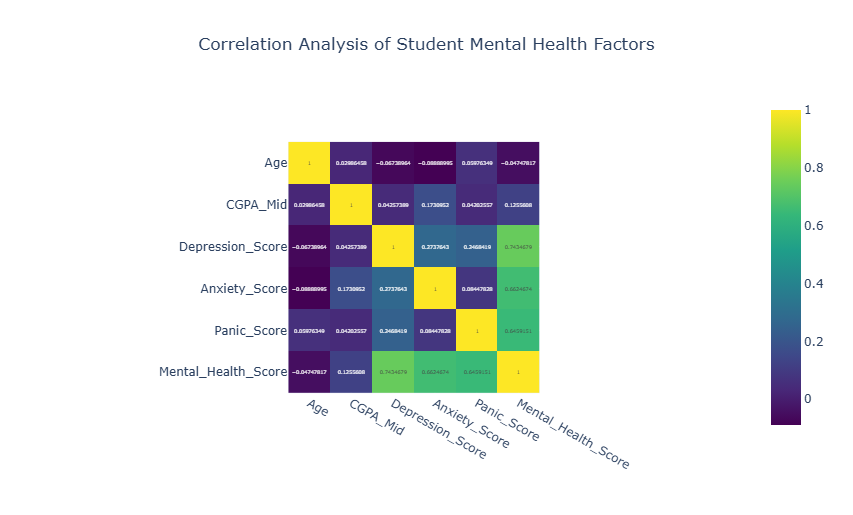

In [28]:
import plotly.express as px

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='Viridis',
    title='Correlation Analysis of Student Mental Health Factors'
)

fig.update_layout(
    width=1000,
    height=500,
    title_x=0.5
)

fig.show()

In [29]:
#SORT(5)

In [30]:
df.sort_values(by='Age', ascending=False)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Age_Group,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
29,8/7/2020 14:05,Female,24.0,BCS,year 4,3.50 - 4.00,No,No,No,No,No,24+,0,0,0,0,3.75
16,8/7/2020 12:46,Female,24.0,Accounting,year 3,3.00 - 3.49,No,No,No,No,No,24+,0,0,0,0,3.25
15,8/7/2020 12:43,Male,24.0,BCS,Year 3,3.50 - 4.00,No,No,No,No,No,24+,0,0,0,0,3.75
17,8/7/2020 12:52,Female,24.0,ENM,year 4,3.00 - 3.49,Yes,Yes,Yes,Yes,No,24+,1,1,1,3,3.25
11,8/7/2020 12:39,Female,24.0,Engineering,Year 3,3.50 - 4.00,Yes,Yes,No,No,No,24+,1,0,0,1,3.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,13/07/2020 11:46:13,Female,18.0,psychology,year 1,3.50 - 4.00,No,Yes,Yes,Yes,No,18-20,1,1,1,3,3.75
91,13/07/2020 14:38:12,Male,18.0,Koe,Year 2,3.00 - 3.49,No,No,Yes,No,No,18-20,0,1,0,1,3.25
93,13/07/2020 16:15:13,Female,18.0,BENL,year 1,3.00 - 3.49,No,Yes,No,No,No,18-20,1,0,0,1,3.25
95,13/07/2020 19:08:32,Female,18.0,Islamic Education,year 1,3.50 - 4.00,No,No,No,No,No,18-20,0,0,0,0,3.75


In [31]:
df.sort_values(by='CGPA_Mid', ascending=False)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Age_Group,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
11,8/7/2020 12:39,Female,24.0,Engineering,Year 3,3.50 - 4.00,Yes,Yes,No,No,No,24+,1,0,0,1,3.75
9,8/7/2020 12:39,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No,18-20,0,1,1,2,3.75
7,8/7/2020 12:33,Female,18.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No,18-20,0,1,0,1,3.75
6,8/7/2020 12:32,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No,21-23,1,0,1,2,3.75
5,8/7/2020 12:31,Male,19.0,Engineering,Year 2,3.50 - 4.00,No,No,No,Yes,No,18-20,0,0,1,1,3.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,13/07/2020 11:54:58,Male,24.0,Engineering,Year 2,2.00 - 2.49,No,No,No,Yes,No,24+,0,0,1,1,2.25
43,8/7/2020 15:07,Male,19.0,BIT,year 1,0 - 1.99,No,No,No,No,No,18-20,0,0,0,0,1.00
73,9/7/2020 6:57,Male,18.0,Biomedical science,year 1,0 - 1.99,No,No,No,No,No,18-20,0,0,0,0,1.00
78,13/07/2020 10:07:32,Female,19.0,Biotechnology,Year 3,0 - 1.99,No,No,No,No,No,18-20,0,0,0,0,1.00


In [32]:
df[df['Do you have Depression?'] == 'Yes']

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Age_Group,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No,18-20,1,0,1,2,3.25
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,18-20,1,1,1,3,3.25
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No,21-23,1,0,0,1,3.25
6,8/7/2020 12:32,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No,21-23,1,0,1,2,3.75
11,8/7/2020 12:39,Female,24.0,Engineering,Year 3,3.50 - 4.00,Yes,Yes,No,No,No,24+,1,0,0,1,3.75
12,8/7/2020 12:40,Female,18.0,BCS,year 1,3.00 - 3.49,No,Yes,No,No,No,18-20,1,0,0,1,3.25
17,8/7/2020 12:52,Female,24.0,ENM,year 4,3.00 - 3.49,Yes,Yes,Yes,Yes,No,24+,1,1,1,3,3.25
19,8/7/2020 13:07,Female,18.0,Marine science,year 2,3.50 - 4.00,Yes,Yes,Yes,Yes,No,18-20,1,1,1,3,3.75
24,8/7/2020 13:17,Female,23.0,BCS,Year 3,3.50 - 4.00,No,Yes,Yes,Yes,No,21-23,1,1,1,3,3.75
27,8/7/2020 13:41,Male,18.0,Engineering,Year 2,3.00 - 3.49,Yes,Yes,Yes,No,No,18-20,1,1,0,2,3.25


In [33]:
df[df['Do you have Anxiety?'] == 'Yes']

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Age_Group,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No,21-23,0,1,0,1,3.25
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,18-20,1,1,1,3,3.25
7,8/7/2020 12:33,Female,18.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No,18-20,0,1,0,1,3.75
9,8/7/2020 12:39,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No,18-20,0,1,1,2,3.75
14,8/7/2020 12:43,Female,18.0,KENMS,Year 2,3.50 - 4.00,No,No,Yes,No,No,18-20,0,1,0,1,3.75
17,8/7/2020 12:52,Female,24.0,ENM,year 4,3.00 - 3.49,Yes,Yes,Yes,Yes,No,24+,1,1,1,3,3.25
18,8/7/2020 13:05,Female,20.0,BIT,Year 2,3.50 - 4.00,No,No,Yes,No,No,18-20,0,1,0,1,3.75
19,8/7/2020 13:07,Female,18.0,Marine science,year 2,3.50 - 4.00,Yes,Yes,Yes,Yes,No,18-20,1,1,1,3,3.75
24,8/7/2020 13:17,Female,23.0,BCS,Year 3,3.50 - 4.00,No,Yes,Yes,Yes,No,21-23,1,1,1,3,3.75
27,8/7/2020 13:41,Male,18.0,Engineering,Year 2,3.00 - 3.49,Yes,Yes,Yes,No,No,18-20,1,1,0,2,3.25


In [34]:
df[df['Did you seek any specialist for a treatment?'] == 'Yes']

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Age_Group,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
28,8/7/2020 13:58,Female,24.0,BIT,Year 3,3.50 - 4.00,Yes,Yes,Yes,Yes,Yes,24+,1,1,1,3,3.75
33,8/7/2020 14:31,Male,18.0,BCS,Year 2,3.50 - 4.00,Yes,Yes,Yes,No,Yes,18-20,1,1,0,2,3.75
39,8/7/2020 14:56,Female,24.0,Engineering,Year 2,2.50 - 2.99,Yes,Yes,No,Yes,Yes,24+,1,0,1,2,2.75
50,8/7/2020 15:27,Female,23.0,ALA,year 1,2.50 - 2.99,Yes,Yes,No,Yes,Yes,21-23,1,0,1,2,2.75
54,8/7/2020 15:57,Female,19.0,BCS,year 1,3.50 - 4.00,No,Yes,No,Yes,Yes,18-20,1,0,1,2,3.75
85,13/07/2020 10:33:47,Female,18.0,psychology,year 1,3.50 - 4.00,No,Yes,Yes,No,Yes,18-20,1,1,0,2,3.75


In [35]:
df.iloc[0:10]

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Age_Group,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No,18-20,1,0,1,2,3.25
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No,21-23,0,1,0,1,3.25
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,18-20,1,1,1,3,3.25
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No,21-23,1,0,0,1,3.25
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No,21-23,0,0,0,0,3.25
5,8/7/2020 12:31,Male,19.0,Engineering,Year 2,3.50 - 4.00,No,No,No,Yes,No,18-20,0,0,1,1,3.75
6,8/7/2020 12:32,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No,21-23,1,0,1,2,3.75
7,8/7/2020 12:33,Female,18.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No,18-20,0,1,0,1,3.75
8,8/7/2020 12:35,Female,19.0,Human Resources,Year 2,2.50 - 2.99,No,No,No,No,No,18-20,0,0,0,0,2.75
9,8/7/2020 12:39,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No,18-20,0,1,1,2,3.75


In [36]:
df.iloc[20:31]

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Age_Group,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
20,8/7/2020 13:12,Female,19.0,Engineering,year 1,3.00 - 3.49,No,No,No,Yes,No,18-20,0,0,1,1,3.25
21,8/7/2020 13:13,Female,18.0,KOE,Year 2,3.00 - 3.49,No,No,No,No,No,18-20,0,0,0,0,3.25
22,8/7/2020 13:13,Female,24.0,BCS,year 1,3.50 - 4.00,No,No,No,No,No,24+,0,0,0,0,3.75
23,8/7/2020 13:15,Female,24.0,Engineering,year 1,3.00 - 3.49,No,No,No,No,No,24+,0,0,0,0,3.25
24,8/7/2020 13:17,Female,23.0,BCS,Year 3,3.50 - 4.00,No,Yes,Yes,Yes,No,21-23,1,1,1,3,3.75
25,8/7/2020 13:29,Female,18.0,Banking Studies,year 1,3.50 - 4.00,No,No,No,No,No,18-20,0,0,0,0,3.75
26,8/7/2020 13:35,Female,19.0,Engineering,year 1,3.50 - 4.00,No,No,No,No,No,18-20,0,0,0,0,3.75
27,8/7/2020 13:41,Male,18.0,Engineering,Year 2,3.00 - 3.49,Yes,Yes,Yes,No,No,18-20,1,1,0,2,3.25
28,8/7/2020 13:58,Female,24.0,BIT,Year 3,3.50 - 4.00,Yes,Yes,Yes,Yes,Yes,24+,1,1,1,3,3.75
29,8/7/2020 14:05,Female,24.0,BCS,year 4,3.50 - 4.00,No,No,No,No,No,24+,0,0,0,0,3.75


In [37]:
df.iloc[:, 0:5]

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study
0,8/7/2020 12:02,Female,18.0,Engineering,year 1
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2
2,8/7/2020 12:05,Male,19.0,BIT,Year 1
3,8/7/2020 12:06,Female,22.0,Laws,year 3
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4
...,...,...,...,...,...
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1
97,13/07/2020 21:21:42,Male,18.0,Engineering,Year 2
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3
99,13/07/2020 21:23:57,Female,23.0,Pendidikan Islam,year 4


In [38]:
df.iloc[-10:]

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Age_Group,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
91,13/07/2020 14:38:12,Male,18.0,Koe,Year 2,3.00 - 3.49,No,No,Yes,No,No,18-20,0,1,0,1,3.25
92,13/07/2020 14:48:05,Female,19.0,KOE,year 2,3.00 - 3.49,Yes,Yes,No,No,No,18-20,1,0,0,1,3.25
93,13/07/2020 16:15:13,Female,18.0,BENL,year 1,3.00 - 3.49,No,Yes,No,No,No,18-20,1,0,0,1,3.25
94,13/07/2020 17:30:44,Female,24.0,Fiqh,Year 3,0 - 1.99,No,No,No,Yes,No,24+,0,0,1,1,1.00
95,13/07/2020 19:08:32,Female,18.0,Islamic Education,year 1,3.50 - 4.00,No,No,No,No,No,18-20,0,0,0,0,3.75
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No,21-23,0,1,0,1,3.75
97,13/07/2020 21:21:42,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No,18-20,1,1,0,2,3.25
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No,18-20,1,0,1,2,3.75
99,13/07/2020 21:23:57,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No,21-23,0,0,0,0,3.75
100,18/07/2020 20:16:21,Male,20.0,Biomedical science,Year 2,3.00 - 3.49,No,No,No,No,No,18-20,0,0,0,0,3.25


In [39]:
df.loc[df['Age'] > 22]

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Age_Group,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No,21-23,0,0,0,0,3.25
6,8/7/2020 12:32,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No,21-23,1,0,1,2,3.75
11,8/7/2020 12:39,Female,24.0,Engineering,Year 3,3.50 - 4.00,Yes,Yes,No,No,No,24+,1,0,0,1,3.75
15,8/7/2020 12:43,Male,24.0,BCS,Year 3,3.50 - 4.00,No,No,No,No,No,24+,0,0,0,0,3.75
16,8/7/2020 12:46,Female,24.0,Accounting,year 3,3.00 - 3.49,No,No,No,No,No,24+,0,0,0,0,3.25
17,8/7/2020 12:52,Female,24.0,ENM,year 4,3.00 - 3.49,Yes,Yes,Yes,Yes,No,24+,1,1,1,3,3.25
22,8/7/2020 13:13,Female,24.0,BCS,year 1,3.50 - 4.00,No,No,No,No,No,24+,0,0,0,0,3.75
23,8/7/2020 13:15,Female,24.0,Engineering,year 1,3.00 - 3.49,No,No,No,No,No,24+,0,0,0,0,3.25
24,8/7/2020 13:17,Female,23.0,BCS,Year 3,3.50 - 4.00,No,Yes,Yes,Yes,No,21-23,1,1,1,3,3.75
28,8/7/2020 13:58,Female,24.0,BIT,Year 3,3.50 - 4.00,Yes,Yes,Yes,Yes,Yes,24+,1,1,1,3,3.75


In [40]:
df.loc[df['Choose your gender'] == 'Female']

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Age_Group,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No,18-20,1,0,1,2,3.25
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No,21-23,1,0,0,1,3.25
6,8/7/2020 12:32,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No,21-23,1,0,1,2,3.75
7,8/7/2020 12:33,Female,18.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No,18-20,0,1,0,1,3.75
8,8/7/2020 12:35,Female,19.0,Human Resources,Year 2,2.50 - 2.99,No,No,No,No,No,18-20,0,0,0,0,2.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,13/07/2020 17:30:44,Female,24.0,Fiqh,Year 3,0 - 1.99,No,No,No,Yes,No,24+,0,0,1,1,1.00
95,13/07/2020 19:08:32,Female,18.0,Islamic Education,year 1,3.50 - 4.00,No,No,No,No,No,18-20,0,0,0,0,3.75
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No,21-23,0,1,0,1,3.75
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No,18-20,1,0,1,2,3.75


In [41]:
df.loc[df['Mental_Health_Score'] >= 2]

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Age_Group,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No,18-20,1,0,1,2,3.25
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,18-20,1,1,1,3,3.25
6,8/7/2020 12:32,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No,21-23,1,0,1,2,3.75
9,8/7/2020 12:39,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No,18-20,0,1,1,2,3.75
17,8/7/2020 12:52,Female,24.0,ENM,year 4,3.00 - 3.49,Yes,Yes,Yes,Yes,No,24+,1,1,1,3,3.25
19,8/7/2020 13:07,Female,18.0,Marine science,year 2,3.50 - 4.00,Yes,Yes,Yes,Yes,No,18-20,1,1,1,3,3.75
24,8/7/2020 13:17,Female,23.0,BCS,Year 3,3.50 - 4.00,No,Yes,Yes,Yes,No,21-23,1,1,1,3,3.75
27,8/7/2020 13:41,Male,18.0,Engineering,Year 2,3.00 - 3.49,Yes,Yes,Yes,No,No,18-20,1,1,0,2,3.25
28,8/7/2020 13:58,Female,24.0,BIT,Year 3,3.50 - 4.00,Yes,Yes,Yes,Yes,Yes,24+,1,1,1,3,3.75
33,8/7/2020 14:31,Male,18.0,BCS,Year 2,3.50 - 4.00,Yes,Yes,Yes,No,Yes,18-20,1,1,0,2,3.75


In [42]:
#VISUALS(6)

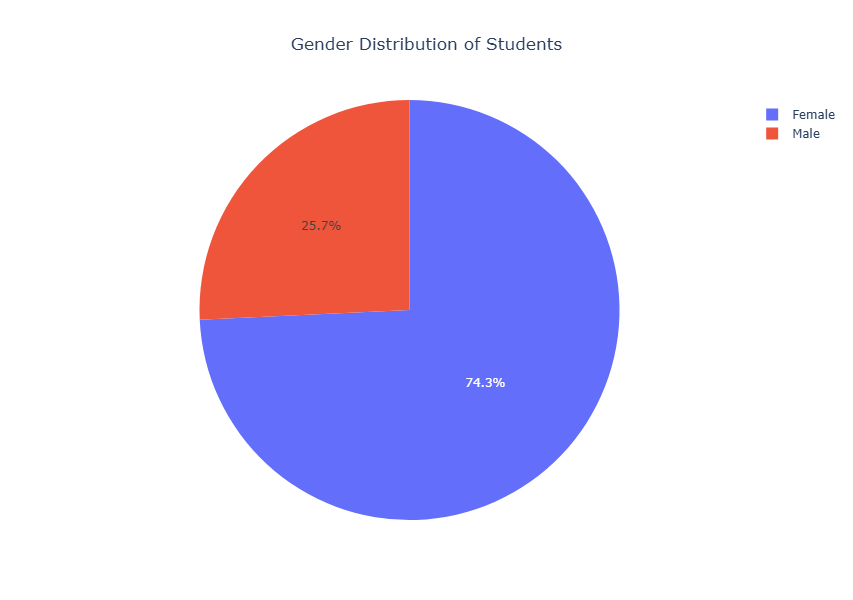

In [43]:
import plotly.express as px

fig1 = px.pie(
    df,
    names='Choose your gender',
    title='Gender Distribution of Students'
)

fig1.update_layout(
    width=800,
    height=600,
    title_x=0.5
)

fig1.show()

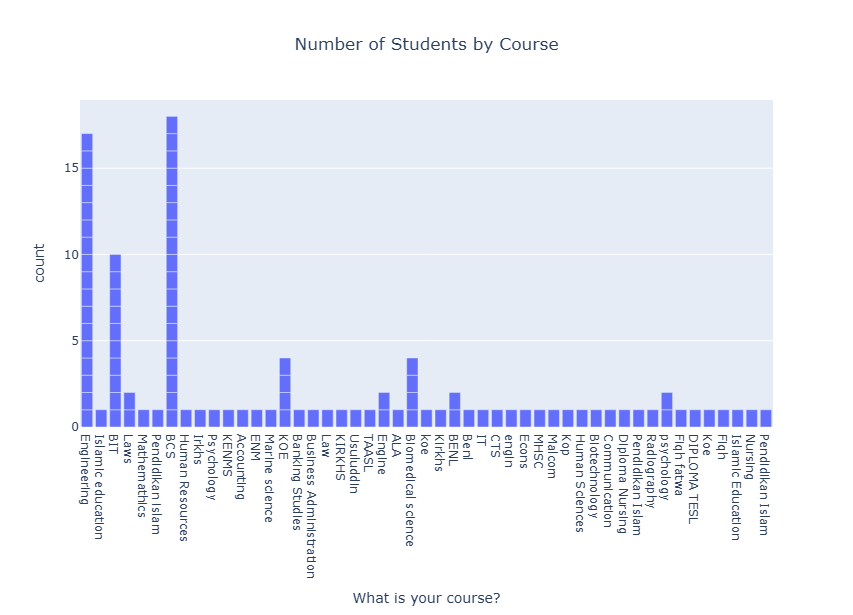

In [44]:
fig2 = px.bar(
    df,
    x='What is your course?',
    title='Number of Students by Course'
)

fig2.update_layout(
    width=1000,
    height=600,
    title_x=0.5
)

fig2.show()

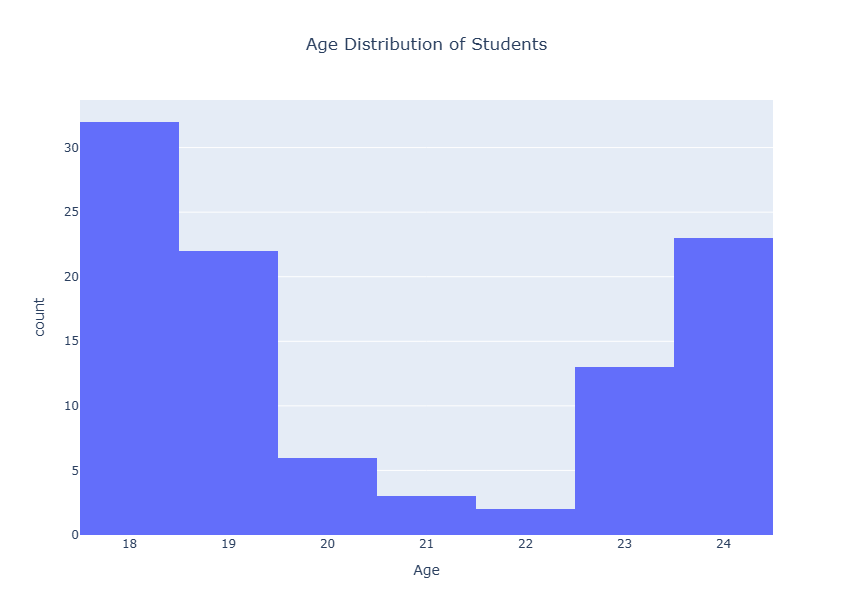

In [45]:
fig3 = px.histogram(
    df,
    x='Age',
    nbins=10,
    title='Age Distribution of Students'
)

fig3.update_layout(
    width=900,
    height=600,
    title_x=0.5
)

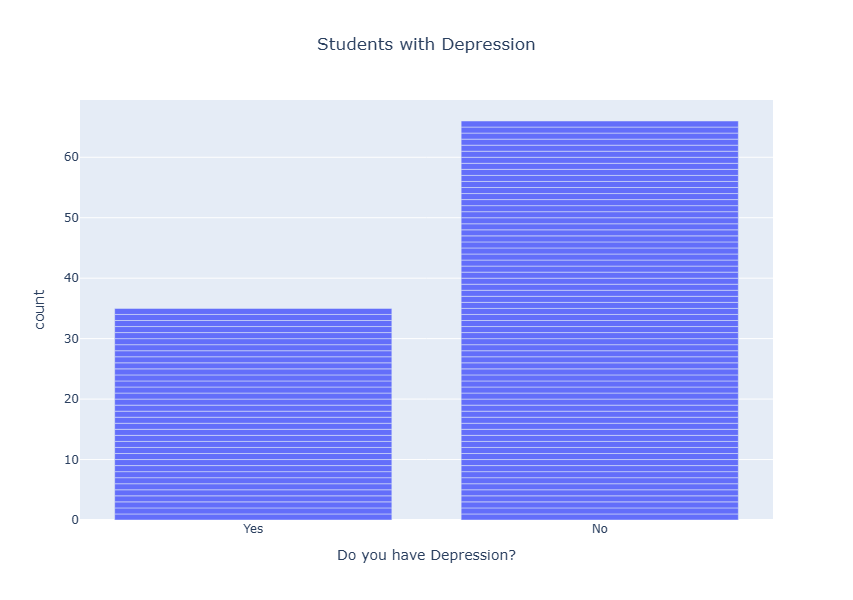

In [46]:
fig4 = px.bar(
    df,
    x='Do you have Depression?',
    title='Students with Depression'
)

fig4.update_layout(
    width=800,
    height=600,
    title_x=0.5
)

fig4.show()

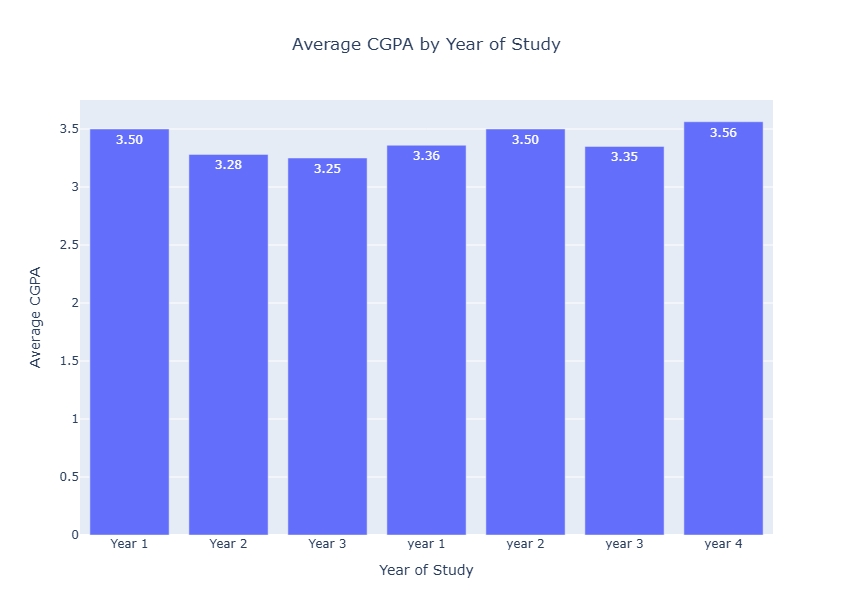

In [47]:
avg_cgpa = (
    df.groupby('Your current year of Study')['CGPA_Mid']
    .mean()
    .reset_index()
)

fig6 = px.bar(
    avg_cgpa,
    x='Your current year of Study',
    y='CGPA_Mid',
    title='Average CGPA by Year of Study',
    text_auto='.2f'
)

fig6.update_layout(
    width=900,
    height=600,
    title_x=0.5,
    xaxis_title='Year of Study',
    yaxis_title='Average CGPA'
)

fig6.show()

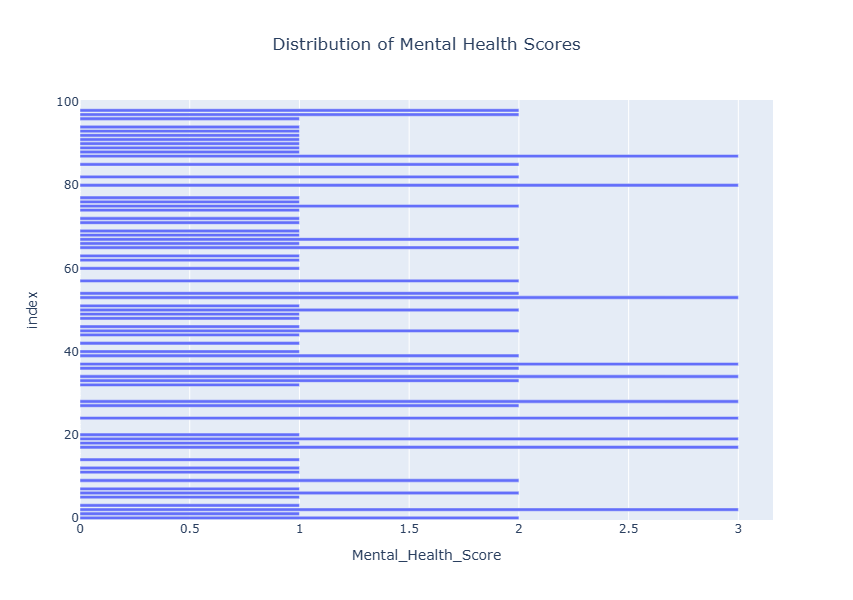

In [48]:
fig5 = px.bar(
    df,
    x='Mental_Health_Score',
    title='Distribution of Mental Health Scores'
)

fig5.update_layout(
    width=800,
    height=600,
    title_x=0.5
)

In [49]:
df.describe()

,Age,Depression_Score,Anxiety_Score,Panic_Score,Mental_Health_Score,CGPA_Mid
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,20.514851,0.346535,0.336634,0.326733,1.009901,3.358911
std,2.488429,0.478239,0.474915,0.471358,0.974629,0.583541
min,18.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,3.250000
50%,19.000000,0.000000,0.000000,0.000000,1.000000,3.250000
75%,23.000000,1.000000,1.000000,1.000000,2.000000,3.750000
max,24.000000,1.000000,1.000000,1.000000,3.000000,3.750000


In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,101.0,20.514851,2.488429,18.0,18.00,19.00,23.00,24.00
Depression_Score,101.0,0.346535,0.478239,0.0,0.00,0.00,1.00,1.00
Anxiety_Score,101.0,0.336634,0.474915,0.0,0.00,0.00,1.00,1.00
Panic_Score,101.0,0.326733,0.471358,0.0,0.00,0.00,1.00,1.00
Mental_Health_Score,101.0,1.009901,0.974629,0.0,0.00,1.00,2.00,3.00
CGPA_Mid,101.0,3.358911,0.583541,1.0,3.25,3.25,3.75,3.75


In [51]:
df.describe(include='object').T

C:\Users\user\AppData\Local\Temp\ipykernel_11228\1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
Timestamp,101,92,8/7/2020 12:39,3
Choose your gender,101,2,Female,75
What is your course?,101,49,BCS,18
Your current year of Study,101,7,year 1,41
What is your CGPA?,101,5,3.50 - 4.00,48
Marital status,101,2,No,85
Do you have Depression?,101,2,No,66
Do you have Anxiety?,101,2,No,67
Do you have Panic attack?,101,2,No,68
Did you seek any specialist for a treatment?,101,2,No,95


In [52]:
df['Depression_Target'] = df['Do you have Depression?'].str.strip().map({'Yes': 1, 'No': 0})

In [53]:
df[['Do you have Depression?', 'Depression_Target']].head(10)

,Do you have Depression?,Depression_Target
0,Yes,1
1,No,0
2,Yes,1
3,Yes,1
4,No,0
5,No,0
6,Yes,1
7,No,0
8,No,0
9,No,0


In [54]:
X = df[
    ['Age',
     'CGPA_Mid',
     'Anxiety_Score',
     'Panic_Score']
]

y = df['Depression_Target']

In [60]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sklearn.model_selection import train_test_split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
X = df[['Age', 'CGPA_Mid', 'Anxiety_Score', 'Panic_Score']]
y = df['Depression_Target']

In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [58]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7142857142857143


In [60]:
y_pred = model.predict(X_test)

print("Actual:", y_test.values)
print("Predicted:", y_pred)

Actual: [0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0]
Predicted: [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [61]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[14  0]
 [ 6  1]]


In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.70      1.00      0.82        14
           1       1.00      0.14      0.25         7

    accuracy                           0.71        21
   macro avg       0.85      0.57      0.54        21
weighted avg       0.80      0.71      0.63        21

